# Constructing a Spatial Manifold M_C from OSMnx Street Network Features

## Design notes

### What is a point on M_C?
Each station becomes a single point on the spatial manifold M_C,  
defined by the distribution of street network geometry within an 800m walking-radius buffer.

Parallel to M_U (pedestrian trajectory manifold), each edge or node is one observation,  
and a distribution is fitted per feature.

### Feature schema

| Feature | Unit of obs. | Distribution | Meaning |
|---|---|---|---|
| `edge_length` | edge [m] | Log-normal | Scale of street segments |
| `circuity_mapped` | edge | Beta | Directness of each segment (actual / straight-line distance) |
| `node_degree` | node | Gamma | Intersection complexity |
| `betweenness_centrality` | node | Beta | Node centrality in network flow (normalized) |
| `bearing_rad` | edge | Von-Mises | Street orientation (circular distribution) |

Plus two scalar coordinates (not fitted, appended directly):
- `edge_density_km`: street km per km² (network density)

### M_C vs M_U comparison
After constructing M_C, we compare pairwise M_C distances with Sym-KL from M_U  
to test whether spatial structure predicts pedestrian behavioral differences.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from scipy.stats import lognorm, beta as beta_dist, gamma as gamma_dist, vonmises
from scipy.special import digamma, i0, i1
from pathlib import Path
import osmnx as ox
import networkx as nx

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

BASE_DIR        = Path("..")
OUTPUT_DIR      = BASE_DIR / "output" / "analysis" / "manifold_spatial"
GRAPH_CACHE_DIR = BASE_DIR / "input" / "networks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_CACHE_DIR.mkdir(parents=True, exist_ok=True)

MANIFOLD_U_DIR = BASE_DIR / "output" / "manifold"  # M_U export from manifold_stations.ipynb
NETWORK_RADIUS = 420  # metres (walk distance)

print(f"Graph cache directory: {GRAPH_CACHE_DIR.resolve()}")


Graph cache directory: H:\01_development\demogracy_map\people_trajectory\input\networks


## 1. Station configuration

In [2]:
with open(BASE_DIR / 'stations.json', encoding='utf-8') as f:
    ALL_STATIONS = json.load(f)

STATIONS = {k: v for k, v in ALL_STATIONS.items() if v['status'] == 'analysis_ready'}
keys = list(STATIONS.keys())
n    = len(keys)
print(f'Stations: {keys}')

Stations: ['Ginza1', 'Ginza2', 'Shinjuku', 'Kamata', 'Shinbashi']


## 2. Street network extraction

For each station, download the walk network within `NETWORK_RADIUS` metres.

In [3]:
def load_or_fetch_graph(key, lat, lon, radius, cache_dir):
    """
    Load a projected walk-network graph from cache (GraphML) if available,
    otherwise download from OSM, add edge bearings (requires unprojected lat/lon),
    project to metric CRS, and save to cache.

    Bearings are added before projection because ox.bearing.add_edge_bearings
    raises ValueError on projected graphs (OSMnx 2.x).
    The bearing edge attribute is preserved through projection and GraphML serialization.
    """
    cache_path = cache_dir / f"{key}_walk_{radius}m.graphml"

    if cache_path.exists():
        G = ox.load_graphml(cache_path)
        # Verify bearing attributes are present (absent in old cache without this fix)
        has_bearings = any("bearing" in d for _, _, d in G.edges(data=True))
        if has_bearings:
            print(f"  [{key}] Loaded from cache: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
            return G
        print(f"  [{key}] Cache missing bearing attributes, re-fetching...")
        cache_path.unlink()

    print(f"  [{key}] Fetching from OSM ({lat}, {lon}), radius={radius}m ...")
    G = ox.graph_from_point(
        (lat, lon),
        dist=radius,
        network_type="walk",
        retain_all=False,
    )
    # Add bearings BEFORE projecting — requires lat/lon (unprojected) coordinates
    G = ox.bearing.add_edge_bearings(G)
    # Project to metric CRS for accurate length/circuity calculations
    G = ox.projection.project_graph(G)
    ox.save_graphml(G, cache_path)
    print(f"  [{key}] {G.number_of_nodes()} nodes, {G.number_of_edges()} edges -> saved to cache")
    return G


graphs = {}
for key, s in STATIONS.items():
    graphs[key] = load_or_fetch_graph(
        key, s["lat"], s["lon"],
        radius=NETWORK_RADIUS,
        cache_dir=GRAPH_CACHE_DIR,
    )


  [Ginza1] Loaded from cache: 1224 nodes, 3794 edges
  [Ginza2] Loaded from cache: 1228 nodes, 3798 edges
  [Shinjuku] Loaded from cache: 1582 nodes, 4576 edges
  [Kamata] Loaded from cache: 614 nodes, 1838 edges
  [Shinbashi] Loaded from cache: 1146 nodes, 3440 edges


## 3. Feature extraction

Per-edge and per-node features for distribution fitting.

In [4]:
def extract_network_features(G):
    """
    Extract edge-level and node-level features from a projected OSMnx graph.
    Requires that edge bearing attributes were added before projection
    (via load_or_fetch_graph).

    Returns:
      edge_length      : ndarray [m]        (Log-normal)
      circuity_mapped  : ndarray [0,1]       (Beta)
      node_degree      : ndarray             (Gamma)
      edge_density_km  : float scalar
    """
    edges = ox.graph_to_gdfs(G, nodes=False)

    # --- Edge length [m] ---
    edge_lengths = edges["length"].dropna().values
    edge_lengths = edge_lengths[edge_lengths > 0]

    # --- Circuity: actual_length / straight-line distance (projected coords) ---
    # Computed in projected (UTM) space; valid approximation for conformal projection.
    def _circuity(row):
        geom   = row.get("geometry")
        length = row.get("length", float("nan"))
        if geom is None or length <= 0:
            return float("nan")
        coords = list(geom.coords)
        if len(coords) < 2:
            return float("nan")
        dx = coords[-1][0] - coords[0][0]
        dy = coords[-1][1] - coords[0][1]
        straight = np.sqrt(dx**2 + dy**2)
        if straight < 1e-3:
            return float("nan")
        return length / straight

    circuity_vals = edges.apply(_circuity, axis=1).dropna().values
    circuity_vals = np.clip(circuity_vals, 1.0, None)
    c_max = np.percentile(circuity_vals, 99)
    circuity_mapped = np.clip(
        (circuity_vals - 1.0) / max(c_max - 1.0, 1e-6), 0.001, 0.999
    )

    # --- Node degree ---
    node_degrees = np.array([d for _, d in G.degree()])
    node_degrees = node_degrees[node_degrees > 0].astype(float)

    # --- Betweenness centrality (normalized, undirected, length-weighted) ---
    # Each node's betweenness value in [0, 1] is one sample.
    # Clipped to (0.001, 0.999) for Beta distribution fitting.
    G_undirected = ox.convert.to_undirected(G)
    betweenness_raw = nx.betweenness_centrality(
        G_undirected,
        normalized=True,
        weight='length',
    )
    betweenness_vals = np.clip(
        np.array(list(betweenness_raw.values())), 0.001, 0.999
    )

    # --- Bearing: undirected doubling trick ---
    # OSMnx directed graphs have each physical street in both directions
    # (e.g. 90 deg and 270 deg for the same east-west road).
    # Fitting Von-Mises directly gives kappa=0 because opposite directions cancel.
    # Fix: fold to [0, 180) then double to [0, 360) -> unimodal circular distribution.
    # The fitted mu corresponds to 2 * dominant axis direction; kappa is unchanged.
    bearing_deg = np.array(
        [d["bearing"] for _, _, d in G.edges(data=True) if "bearing" in d]
    )
    if len(bearing_deg) > 0:
        bearing_fold    = bearing_deg % 180.0              # fold to [0, 180)
        bearing_doubled = np.deg2rad(bearing_fold * 2.0)   # double -> [0, 2pi)
        bearing_rad_arr = np.where(bearing_doubled > np.pi,
                                   bearing_doubled - 2 * np.pi,
                                   bearing_doubled)         # wrap to [-pi, pi] for vonmises
    else:
        print("  Warning: no bearing attributes on edges — re-run load_or_fetch_graph")
        bearing_rad_arr = np.array([0.0])

    # --- Edge density (street km per km²) ---
    total_edge_length_km = edge_lengths.sum() / 1000.0
    area_km2 = np.pi * (NETWORK_RADIUS / 1000.0) ** 2
    edge_density_km = float(total_edge_length_km / area_km2)

    return {
        "edge_length":              edge_lengths,
        "circuity_mapped":          circuity_mapped,
        "node_degree":              node_degrees,
        "betweenness_centrality":   betweenness_vals,
        "bearing_rad":              bearing_rad_arr,
        "edge_density_km":          edge_density_km,     # scalar — not in SPATIAL_SCHEMA
    }


station_net_features = {}
for key in keys:
    feats = extract_network_features(graphs[key])
    station_net_features[key] = feats
    print(
        f"{key}: edges={len(feats['edge_length'])}, nodes={len(feats['node_degree'])}, "
        f"bearings={len(feats['bearing_rad'])}, "
        f"edge_density={feats['edge_density_km']:.2f} km/km2"
    )


Ginza1: edges=3794, nodes=1224, bearings=3790, edge_density=177.89 km/km2
Ginza2: edges=3798, nodes=1228, bearings=3794, edge_density=178.12 km/km2
Shinjuku: edges=4576, nodes=1582, bearings=4574, edge_density=196.20 km/km2
Kamata: edges=1838, nodes=614, bearings=1836, edge_density=109.69 km/km2
Shinbashi: edges=3440, nodes=1146, bearings=3440, edge_density=157.19 km/km2


## 4. Distribution schema for M_C

| Feature | Distribution | Parameters |
|---|---|---|
| `edge_length` | Log-normal | (s, loc=0, scale) |
| `circuity_mapped` | Beta | (α, β) |
| `node_degree` | Gamma | (a, loc=0, scale) |
| `betweenness_centrality` | Beta | (α, β) |
| `bearing_rad` | Von-Mises | (κ, μ, scale=1) |

Scalar feature (`edge_density_km`) is appended directly as a fixed coordinate  
and is not converted to θ/η (it has no distributional interpretation).


In [5]:
SPATIAL_SCHEMA = [
    # (feature_key, dist_name, scipy_dist)
    ('edge_length',             'Log-normal', lognorm),
    ('circuity_mapped',         'Beta',       beta_dist),
    ('node_degree',             'Gamma',      gamma_dist),
    ('betweenness_centrality',  'Beta',       beta_dist),
    ('bearing_rad',             'Von-Mises',  vonmises),
]


def fit_spatial_station(feats):
    """Fit all distributions for one station's network features.
    Returns dict: feature -> {'dist', 'params', 'n'}
    """
    result = {}
    for feat_key, dist_name, dist_obj in SPATIAL_SCHEMA:
        data = feats[feat_key]
        data = data[np.isfinite(data)]
        if len(data) < 10:
            print(f'  Warning: {feat_key} has only {len(data)} samples')
            result[feat_key] = None
            continue

        if dist_name == 'Log-normal':
            params = dist_obj.fit(data, floc=0)
        elif dist_name == 'Beta':
            params = dist_obj.fit(data, floc=0, fscale=1)
        elif dist_name == 'Gamma':
            params = dist_obj.fit(data, floc=0)
        elif dist_name == 'Von-Mises':
            params = dist_obj.fit(data, fscale=1)  # returns (kappa, loc=mu, scale=1)
        else:
            params = dist_obj.fit(data)

        result[feat_key] = {
            'dist':   dist_name,
            'params': params,
            'n':      len(data),
        }
    return result


station_spatial_fits = {}
for key in keys:
    fits = fit_spatial_station(station_net_features[key])
    station_spatial_fits[key] = fits
    print(f'\n{key}:')
    for feat_key, info in fits.items():
        if info:
            print(f'  {feat_key} ({info["dist"]}): params={[round(p, 4) for p in info["params"]]}, n={info["n"]}')


Ginza1:
  edge_length (Log-normal): params=[np.float64(1.1178), 0, np.float64(14.2834)], n=3794
  circuity_mapped (Beta): params=[np.float64(0.2075), np.float64(2.4501), 0, 1], n=3790
  node_degree (Gamma): params=[9.6317, 0, np.float64(0.6436)], n=1224
  betweenness_centrality (Beta): params=[np.float64(0.8228), np.float64(41.8849), 0, 1], n=1224
  bearing_rad (Von-Mises): params=[0.0623, np.float64(-3.0861), 1], n=3790

Ginza2:
  edge_length (Log-normal): params=[np.float64(1.1158), 0, np.float64(14.3307)], n=3798
  circuity_mapped (Beta): params=[np.float64(0.2075), np.float64(2.4401), 0, 1], n=3794
  node_degree (Gamma): params=[9.3871, 0, np.float64(0.659)], n=1228
  betweenness_centrality (Beta): params=[np.float64(0.8211), np.float64(41.9422), 0, 1], n=1228
  bearing_rad (Von-Mises): params=[0.0616, np.float64(-3.0891), 1], n=3794

Shinjuku:
  edge_length (Log-normal): params=[np.float64(1.0273), 0, np.float64(14.4278)], n=4576
  circuity_mapped (Beta): params=[np.float64(0.204

## 5. Dual flat structure: θ and η coordinates for M_C

Same conversion as M_U (manifold_stations.ipynb), applied to 5 distribution families:

| Distribution | θ | η |
|---|---|---|
| Log-normal(s, scale) | (m/s², −1/2s²) where m=log(scale) | (m, m²+s²) |
| Beta(α, β) | (α−1, β−1) | (ψ(α)−ψ(α+β), ψ(β)−ψ(α+β)) |
| Gamma(a, scale) | (a−1, −1/scale) | (ψ(a)+log(scale), a·scale) |
| Von-Mises(κ, μ) | (κ cos μ, κ sin μ) | (A(κ) cos μ, A(κ) sin μ) where A(κ)=I₁(κ)/I₀(κ) |

Total θ/η dimension: 2 (Log-normal) + 2 (Beta) + 2 (Gamma) + 2 (Beta) + 2 (Von-Mises) = **10 dimensions**  
Plus 1 scalar coordinate: `edge_density_km` → **11-dimensional M_C point**

Scalar features have no distributional interpretation and are excluded from the dually flat structure.


In [17]:
def spatial_to_natural_params(feat_key, params):
    """Convert fitted scipy params to natural parameters theta for spatial features."""
    dist_name = next(r[1] for r in SPATIAL_SCHEMA if r[0] == feat_key)

    if dist_name == 'Log-normal':
        s, loc, scale = params
        m = np.log(scale)
        return (m / s**2, -1.0 / (2 * s**2))

    elif dist_name == 'Beta':
        a, b, loc, scale = params
        return (a - 1.0, b - 1.0)

    elif dist_name == 'Gamma':
        a, loc, scale = params
        return (a - 1.0, -1.0 / scale)

    elif dist_name == 'Von-Mises':
        kappa, mu, scale = params
        return (kappa * np.cos(mu), kappa * np.sin(mu))


def spatial_to_expectation_params(feat_key, params):
    """Convert fitted scipy params to expectation parameters eta for spatial features."""
    dist_name = next(r[1] for r in SPATIAL_SCHEMA if r[0] == feat_key)

    if dist_name == 'Log-normal':
        s, loc, scale = params
        m = np.log(scale)
        return (m, m**2 + s**2)

    elif dist_name == 'Beta':
        from scipy.special import digamma
        a, b, loc, scale = params
        psi_ab = digamma(a + b)
        return (digamma(a) - psi_ab, digamma(b) - psi_ab)

    elif dist_name == 'Gamma':
        from scipy.special import digamma
        a, loc, scale = params
        return (digamma(a) + np.log(scale), a * scale)

    elif dist_name == 'Von-Mises':
        from scipy.special import i0, i1
        kappa, mu, scale = params
        A_kappa = i1(kappa) / i0(kappa)  # mean resultant length
        return (A_kappa * np.cos(mu), A_kappa * np.sin(mu))


def station_to_manifold_coords(key):
    """Build full M_C coordinate vector for a station.
    Returns (theta_vec, eta_vec, scalar_vec).
    """
    fits  = station_spatial_fits[key]
    feats = station_net_features[key]

    theta_parts = []
    eta_parts   = []
    for feat_key, _, _ in SPATIAL_SCHEMA:
        info = fits[feat_key]
        if info is None:
            raise ValueError(f'{key}: missing fit for {feat_key}')
        theta_parts.extend(spatial_to_natural_params(feat_key, info['params']))
        eta_parts.extend(spatial_to_expectation_params(feat_key, info['params']))

    theta_vec   = np.array(theta_parts)
    eta_vec     = np.array(eta_parts)
    scalar_vec  = np.array([feats['edge_density_km']])
    return theta_vec, eta_vec, scalar_vec


station_theta_c = {}
station_eta_c   = {}
station_scalar  = {}
for key in keys:
    th, et, sc = station_to_manifold_coords(key)
    station_theta_c[key] = th
    station_eta_c[key]   = et
    station_scalar[key]  = sc

print('theta dimension:', len(station_theta_c[keys[0]]))
print('eta dimension:  ', len(station_eta_c[keys[0]]))
print('scalar dim (edge_density_km only):', len(station_scalar[keys[0]]))

# --- theta coordinate table (manifold coordinates) ---
# Column names reflect the meaning of each theta dimension:
#   edge_length  (Log-normal): theta = (m/s2, -1/2s2)  where m = log(scale)
#   circuity     (Beta):       theta = (alpha-1, beta-1)
#   node_degree  (Gamma):      theta = (a-1, -1/scale)
#   betweenness  (Beta):       theta = (alpha-1, beta-1)
#   bearing_rad  (Von-Mises):  theta = (kappa*cos(mu), kappa*sin(mu))
THETA_COLS = [
    'len:m/s2',    'len:-1/2s2',
    'circ:a-1',    'circ:b-1',
    'deg:a-1',     'deg:-1/sc',
    'btwn:a-1',    'btwn:b-1',
    'bear:k*cos',  'bear:k*sin',
]

rows_theta = []
for key in keys:
    row = {'station': key}
    for col, val in zip(THETA_COLS, station_theta_c[key]):
        row[col] = round(float(val), 4)
    row['edge_density_km'] = round(station_scalar[key][0], 4)
    rows_theta.append(row)

df_theta = pd.DataFrame(rows_theta).set_index('station')
print('=== M_C Manifold Coordinates (theta-space) ===')
df_theta


theta dimension: 10
eta dimension:   10
scalar dim (edge_density_km only): 1
=== M_C Manifold Coordinates (theta-space) ===


,len:m/s2,len:-1/2s2,circ:a-1,circ:b-1,deg:a-1,deg:-1/sc,btwn:a-1,btwn:b-1,bear:k*cos,bear:k*sin,edge_density_km
station,,,,,,,,,,,
Ginza1,2.1281,-0.4001,-0.7925,1.4501,8.6317,-1.5537,-0.1772,40.8849,-0.0623,-0.0035,177.8902
Ginza2,2.1385,-0.4016,-0.7925,1.4401,8.3871,-1.5175,-0.1789,40.9422,-0.0615,-0.0032,178.1240
Shinjuku,2.5291,-0.4738,-0.7959,1.3335,4.8897,-1.0181,-0.3197,43.3613,0.1130,0.0216,196.1967
Kamata,2.9538,-0.4843,-0.7795,0.9660,5.3845,-1.0664,-0.3520,21.5502,-0.0228,-0.0567,109.6891
Shinbashi,2.5988,-0.4740,-0.7842,1.3007,5.9866,-1.1638,-0.3110,30.6136,0.0119,0.0035,157.1903


## 5b. Distribution fits: histogram + fitted curve per feature

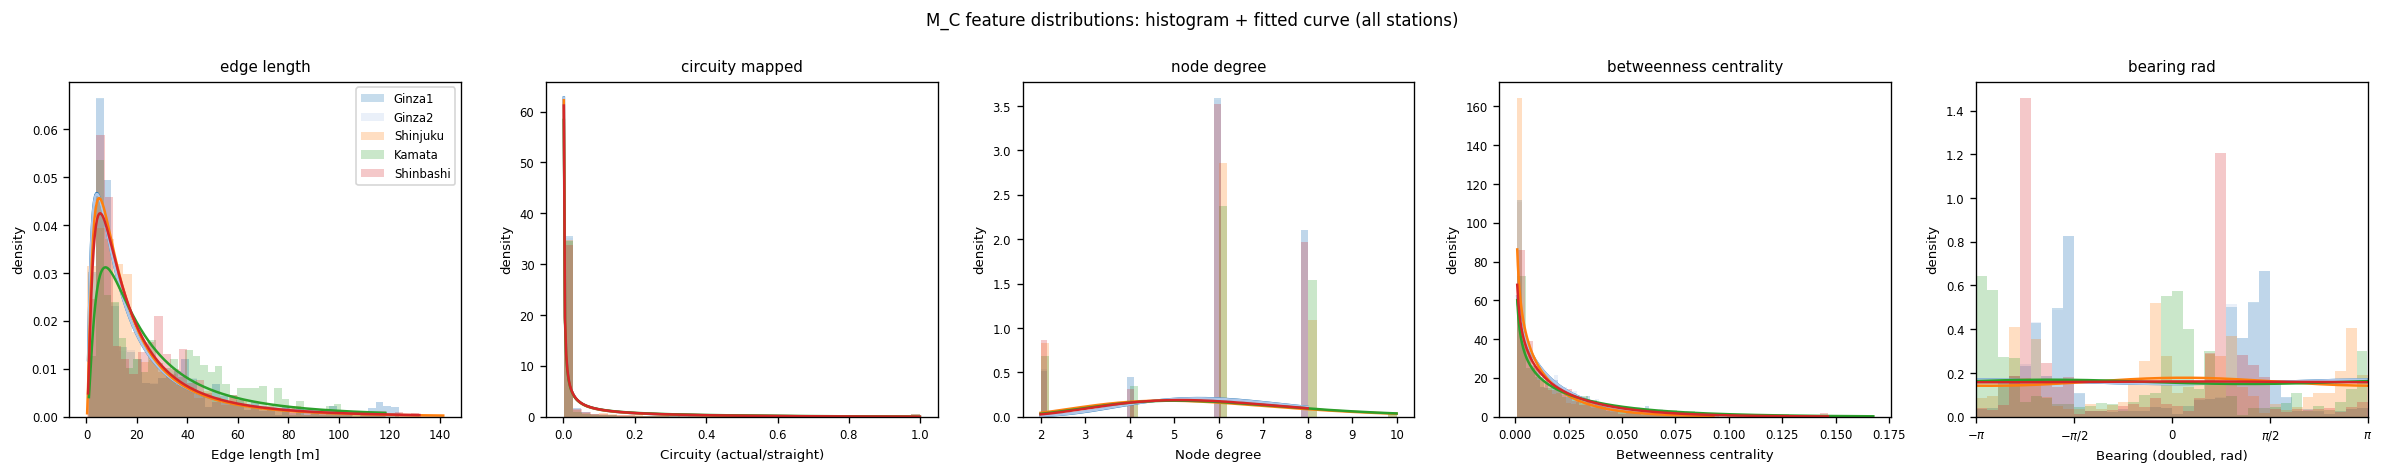

Saved mc_distribution_fits.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import lognorm, beta as beta_dist, gamma as gamma_dist, vonmises

FEAT_PLOT_INFO = [
    ('edge_length',            'Log-normal',  lognorm,     'Edge length [m]'),
    ('circuity_mapped',        'Beta',        beta_dist,   'Circuity (actual/straight)'),
    ('node_degree',            'Gamma',       gamma_dist,  'Node degree'),
    ('betweenness_centrality', 'Beta',        beta_dist,   'Betweenness centrality'),
    ('bearing_rad',            'Von-Mises',   vonmises,    'Bearing (doubled, rad)'),
]

COLORS = {'Ginza1': '#1f77b4', 'Ginza2': '#aec7e8',
          'Shinjuku': '#ff7f0e', 'Kamata': '#2ca02c', 'Shinbashi': '#d62728'}

n_feats = len(FEAT_PLOT_INFO)
fig, axes = plt.subplots(1, n_feats, figsize=(4 * n_feats, 4))

for ax, (feat_key, dist_name, dist_fn, xlabel) in zip(axes, FEAT_PLOT_INFO):
    for key in keys:
        data   = station_net_features[key][feat_key]
        params = station_spatial_fits[key][feat_key]['params']

        if feat_key == 'bearing_rad':
            # Histogram on circular data: use density
            ax.hist(data, bins=36, density=True, alpha=0.25, color=COLORS[key], label=key)
            x = np.linspace(-np.pi, np.pi, 300)
            kappa, mu, scale = params
            ax.plot(x, vonmises.pdf(x, kappa, mu), color=COLORS[key], lw=1.5)
            ax.set_xlim(-np.pi, np.pi)
            ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
            ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
        else:
            clip = np.percentile(data, 99)
            data_clipped = data[data <= clip]
            ax.hist(data_clipped, bins=40, density=True, alpha=0.25,
                    color=COLORS[key], label=key)
            x = np.linspace(data_clipped.min(), data_clipped.max(), 300)
            ax.plot(x, dist_fn.pdf(x, *params), color=COLORS[key], lw=1.5)

    ax.set_title(feat_key.replace('_', ' '), fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('M_C feature distributions: histogram + fitted curve (all stations)', fontsize=10)
plt.tight_layout()
plt.savefig('../output/manifold_spatial/mc_distribution_fits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved mc_distribution_fits.png')


## 6. KL divergence between stations on M_C

In [19]:
def kl_lognormal(params_p, params_q):
    """D_KL( LogNormal(p) || LogNormal(q) )"""
    s_p, _, scale_p = params_p
    s_q, _, scale_q = params_q
    m_p, m_q = np.log(scale_p), np.log(scale_q)
    return (np.log(s_q / s_p)
            + (s_p**2 + (m_p - m_q)**2) / (2 * s_q**2)
            - 0.5)


def kl_beta(params_p, params_q):
    """D_KL( Beta(p) || Beta(q) ) using log-gamma form."""
    from scipy.special import betaln, gammaln
    a1, b1, _, _ = params_p
    a2, b2, _, _ = params_q
    return (
        betaln(a2, b2) - betaln(a1, b1)
        + (a1 - a2) * digamma(a1)
        + (b1 - b2) * digamma(b1)
        + (a2 - a1 + b2 - b1) * digamma(a1 + b1)
    )


def kl_gamma(params_p, params_q):
    """D_KL( Gamma(p) || Gamma(q) )"""
    a1, _, scale1 = params_p
    a2, _, scale2 = params_q
    from scipy.special import gammaln
    return (
        (a1 - a2) * digamma(a1)
        - gammaln(a1) + gammaln(a2)
        + a2 * (np.log(scale2) - np.log(scale1))
        + a1 * (scale1 / scale2 - 1)
    )


def kl_vonmises(params_p, params_q):
    """D_KL( VonMises(kappa1,mu1) || VonMises(kappa2,mu2) )

    Analytical form (derived from exponential family structure):
      D = log(I0(k2)/I0(k1)) + k1*A(k1) - k2*A(k1)*cos(mu1-mu2)
    where A(k) = I1(k)/I0(k).
    """
    k1, mu1, _ = params_p
    k2, mu2, _ = params_q
    A1 = i1(k1) / i0(k1)
    return (np.log(i0(k2) / i0(k1))
            + k1 * A1
            - k2 * A1 * np.cos(mu1 - mu2))


KL_FUNCS = {
    'Log-normal': kl_lognormal,
    'Beta':       kl_beta,
    'Gamma':      kl_gamma,
    'Von-Mises':  kl_vonmises,
}


def kl_spatial(key_p, key_q):
    """Total KL divergence D(M_C_p || M_C_q) summed over distributional features."""
    total = 0.0
    per_feat = {}
    for feat_key, dist_name, _ in SPATIAL_SCHEMA:
        fp = station_spatial_fits[key_p][feat_key]['params']
        fq = station_spatial_fits[key_q][feat_key]['params']
        kl_val = KL_FUNCS[dist_name](fp, fq)
        per_feat[feat_key] = kl_val
        total += kl_val
    return total, per_feat


# KL divergence matrix
kl_matrix_c = np.zeros((n, n))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i != j:
            kl_matrix_c[i, j], _ = kl_spatial(ki, kj)

sym_kl_c = kl_matrix_c + kl_matrix_c.T

print('KL divergence matrix (M_C):')
df_kl = pd.DataFrame(kl_matrix_c, index=keys, columns=keys).round(3)
print(df_kl.to_string())

KL divergence matrix (M_C):
           Ginza1  Ginza2  Shinjuku  Kamata  Shinbashi
Ginza1      0.000   0.000     0.118   0.199      0.056
Ginza2      0.000   0.000     0.110   0.193      0.051
Shinjuku    0.149   0.137     0.000   0.199      0.058
Kamata      0.232   0.224     0.262   0.000      0.085
Shinbashi   0.064   0.058     0.066   0.078      0.000


## 7. e/m geodesics and curvature analysis on M_C

Same dual flat structure as M_U. M_C has **10-dimensional** θ/η space (distributional features only):
- Log-normal(`edge_length`): 2 dims
- Beta(`circuity_mapped`): 2 dims
- Gamma(`node_degree`): 2 dims
- Beta(`betweenness_centrality`): 2 dims
- Von-Mises(`bearing_rad`): 2 dims

`edge_density_km` (1 scalar) is not part of the exponential family structure
and is excluded from the geodesic/curvature analysis.

**e-geodesic**: straight line in θ-space, `θ(t) = (1−t)·θ_A + t·θ_B`  
**m-geodesic**: straight line in η-space, `η(t) = (1−t)·η_A + t·η_B`  

The KL divergence between e-geodesic and m-geodesic at each t measures the curvature of M_C.


Most distant pair (M_C): Shinjuku <-> Kamata  Sym-KL=0.460


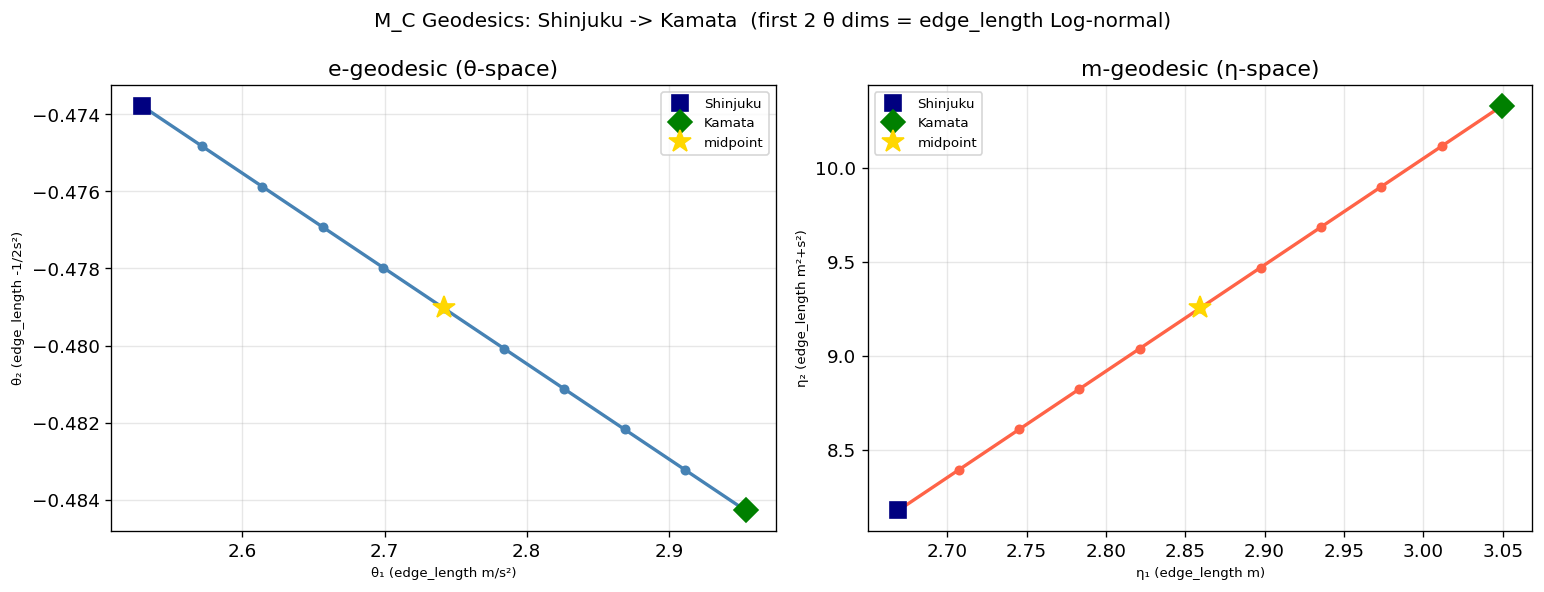

In [20]:
def geodesic_points_c(key_a, key_b, n_steps=11):
    """Return e-geodesic and m-geodesic on M_C as sequences of 6-dim θ/η vectors."""
    theta_a, theta_b = station_theta_c[key_a], station_theta_c[key_b]
    eta_a,   eta_b   = station_eta_c[key_a],   station_eta_c[key_b]
    ts = np.linspace(0, 1, n_steps)
    e_geo = [(1 - t) * theta_a + t * theta_b for t in ts]  # straight in θ
    m_geo = [(1 - t) * eta_a   + t * eta_b   for t in ts]  # straight in η
    return ts, e_geo, m_geo


# Visualize geodesics for the most KL-distant pair
sym_kl_vals_c = [
    (sym_kl_c[i, j], keys[i], keys[j])
    for i in range(n) for j in range(i + 1, n)
]
sym_kl_vals_c.sort(reverse=True)
_, key_a_c, key_b_c = sym_kl_vals_c[0]
print(f'Most distant pair (M_C): {key_a_c} <-> {key_b_c}  Sym-KL={sym_kl_vals_c[0][0]:.3f}')

ts_c, e_geo_c, m_geo_c = geodesic_points_c(key_a_c, key_b_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (geo, label, color) in zip(axes, [
    (e_geo_c, 'e-geodesic (θ-space)', 'steelblue'),
    (m_geo_c, 'm-geodesic (η-space)', 'tomato'),
]):
    pts = np.array(geo)
    ax.plot(pts[:, 0], pts[:, 1], '-o', color=color, lw=2, ms=5)
    ax.plot(pts[0, 0],  pts[0, 1],  's', color='navy',  ms=10, label=key_a_c, zorder=5)
    ax.plot(pts[-1, 0], pts[-1, 1], 'D', color='green', ms=10, label=key_b_c, zorder=5)
    mid = pts[len(pts) // 2]
    ax.plot(mid[0], mid[1], '*', color='gold', ms=14, zorder=6, label='midpoint')
    dim0_label = 'θ₁ (edge_length m/s²)' if 'e-' in label else 'η₁ (edge_length m)'
    dim1_label = 'θ₂ (edge_length -1/2s²)' if 'e-' in label else 'η₂ (edge_length m²+s²)'
    ax.set_xlabel(dim0_label, fontsize=8)
    ax.set_ylabel(dim1_label, fontsize=8)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle(f'M_C Geodesics: {key_a_c} -> {key_b_c}  (first 2 θ dims = edge_length Log-normal)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'mc_geodesics_{key_a_c}_{key_b_c}.png', dpi=150, bbox_inches='tight')
plt.show()


### Inverse Legendre transform for M_C

To measure the KL gap between e-geodesic and m-geodesic at each t,
the m-geodesic point (in η-space) must be converted back to θ-space.

| Distribution | Inversion (η → scipy params) |
|---|---|
| Log-normal | s²=η₁−η₀², scale=exp(η₀)  (exact) |
| Beta | solve ψ(α)−ψ(α+β)=η₀, ψ(β)−ψ(α+β)=η₁  (numerical) |
| Gamma | solve ψ(a)−log(a)+log(η₁)=η₀  (numerical) |
| Von-Mises | κ=A⁻¹(√(η₀²+η₁²)), μ=arctan2(η₁,η₀)  (numerical A⁻¹ via brentq) |


In [21]:
from scipy.optimize import brentq, fsolve

_C_DIST_DIMS = {'Log-normal': 2, 'Beta': 2, 'Gamma': 2, 'Von-Mises': 2}


def _eta_seg_to_scipy_c(dist_name, eta_seg):
    """Invert one η segment to scipy params for M_C distributions."""
    if dist_name == 'Log-normal':
        eta0, eta1 = eta_seg   # eta0=m, eta1=m²+s²
        s2 = eta1 - eta0 ** 2
        s2 = max(s2, 1e-10)
        return (np.sqrt(s2), 0.0, np.exp(eta0))  # (s, loc, scale)

    elif dist_name == 'Beta':
        eta0, eta1 = eta_seg   # ψ(α)−ψ(α+β), ψ(β)−ψ(α+β)
        def eqs(log_ab):
            a, b = np.exp(log_ab)
            ab = a + b
            return [digamma(a) - digamma(ab) - eta0,
                    digamma(b) - digamma(ab) - eta1]
        sol = fsolve(eqs, [0.0, 0.0], full_output=True)
        a_est, b_est = np.exp(sol[0])
        a_est = max(a_est, 1e-6)
        b_est = max(b_est, 1e-6)
        return (a_est, b_est, 0.0, 1.0)  # (a, b, loc, scale)

    elif dist_name == 'Gamma':
        eta0, eta1 = eta_seg   # psi(a)+log(scale), a*scale
        target = eta0 - np.log(max(eta1, 1e-10))
        f = lambda a: digamma(float(a)) - np.log(float(a)) - target
        try:
            a_est = brentq(f, 1e-6, 1e4)
        except ValueError:
            a_est = 1.0
        scale_est = max(eta1 / a_est, 1e-10)
        return (a_est, 0.0, scale_est)  # (a, loc, scale)

    elif dist_name == 'Von-Mises':
        eta0, eta1 = eta_seg   # A(k)*cos(mu), A(k)*sin(mu)
        A_val = np.sqrt(eta0**2 + eta1**2)  # = A(kappa) = I1(k)/I0(k)
        mu_est = np.arctan2(eta1, eta0)
        # Invert A(kappa) = A_val numerically
        A_val = np.clip(A_val, 1e-6, 1 - 1e-6)
        f_k = lambda k: i1(float(k)) / i0(float(k)) - A_val
        try:
            kappa_est = brentq(f_k, 1e-6, 700.0)
        except ValueError:
            kappa_est = 1.0
        return (kappa_est, mu_est, 1.0)  # (kappa, loc=mu, scale=1)

    raise ValueError(f'Unknown distribution: {dist_name}')


def _theta_seg_to_scipy_c(dist_name, theta_seg):
    """Convert one θ segment to scipy params for M_C distributions."""
    if dist_name == 'Log-normal':
        t0, t1 = theta_seg
        s2 = -1.0 / (2.0 * t1)
        m  = t0 * s2
        return (np.sqrt(s2), 0.0, np.exp(m))

    elif dist_name == 'Beta':
        t0, t1 = theta_seg
        return (t0 + 1.0, t1 + 1.0, 0.0, 1.0)

    elif dist_name == 'Gamma':
        t0, t1 = theta_seg
        return (t0 + 1.0, 0.0, -1.0 / t1)

    elif dist_name == 'Von-Mises':
        t0, t1 = theta_seg   # kappa*cos(mu), kappa*sin(mu)
        kappa_est = np.sqrt(t0**2 + t1**2)
        mu_est = np.arctan2(t1, t0)
        return (kappa_est, mu_est, 1.0)  # (kappa, loc=mu, scale=1)

    raise ValueError(f'Unknown distribution: {dist_name}')


def theta_vec_to_scipy_c(theta_vec):
    """Convert 6-dim θ vector to dict of {feat: scipy_params} for M_C."""
    result = {}
    idx = 0
    for feat_key, dist_name, _ in SPATIAL_SCHEMA:
        d = _C_DIST_DIMS[dist_name]
        result[feat_key] = _theta_seg_to_scipy_c(dist_name, theta_vec[idx: idx + d])
        idx += d
    return result


def eta_vec_to_scipy_c(eta_vec):
    """Convert 6-dim η vector to dict of {feat: scipy_params} for M_C."""
    result = {}
    idx = 0
    for feat_key, dist_name, _ in SPATIAL_SCHEMA:
        d = _C_DIST_DIMS[dist_name]
        result[feat_key] = _eta_seg_to_scipy_c(dist_name, eta_vec[idx: idx + d])
        idx += d
    return result


# Sanity check: self-KL should be ~0
for key in keys:
    p = theta_vec_to_scipy_c(station_theta_c[key])
    self_kl = sum(KL_FUNCS[next(r[1] for r in SPATIAL_SCHEMA if r[0] == f)](p[f], p[f])
                  for f in p)
    print(f'{key:12s}  self-KL = {self_kl:.2e}  (should be ~0)')

# Sanity check: η -> scipy -> KL(p, p) should also be ~0
for key in keys:
    q = eta_vec_to_scipy_c(station_eta_c[key])
    self_kl = sum(KL_FUNCS[next(r[1] for r in SPATIAL_SCHEMA if r[0] == f)](q[f], q[f])
                  for f in q)
    print(f'{key:12s}  self-KL (from η) = {self_kl:.2e}')


Ginza1        self-KL = 0.00e+00  (should be ~0)
Ginza2        self-KL = 0.00e+00  (should be ~0)
Shinjuku      self-KL = 0.00e+00  (should be ~0)
Kamata        self-KL = 0.00e+00  (should be ~0)
Shinbashi     self-KL = 0.00e+00  (should be ~0)
Ginza1        self-KL (from η) = 0.00e+00
Ginza2        self-KL (from η) = 0.00e+00
Shinjuku      self-KL (from η) = 0.00e+00
Kamata        self-KL (from η) = 0.00e+00
Shinbashi     self-KL (from η) = 0.00e+00


=== M_C Curvature Summary (sorted by Max Div) ===
                Pair  Sym-KL  Max Div  Mean Div Nonlinearity
   Shinjuku<->Kamata 0.46048  0.00447   0.00272          Low
     Ginza1<->Kamata 0.43114  0.00283   0.00170          Low
     Ginza2<->Kamata 0.41669  0.00270   0.00162          Low
   Ginza1<->Shinjuku 0.26665  0.00154   0.00093          Low
   Ginza2<->Shinjuku 0.24777  0.00128   0.00077          Low
Shinjuku<->Shinbashi 0.12415  0.00041   0.00024          Low
  Kamata<->Shinbashi 0.16320  0.00036   0.00022          Low
  Ginza1<->Shinbashi 0.11973  0.00031   0.00018          Low
  Ginza2<->Shinbashi 0.10884  0.00024   0.00014          Low
     Ginza1<->Ginza2 0.00042  0.00000   0.00000          Low


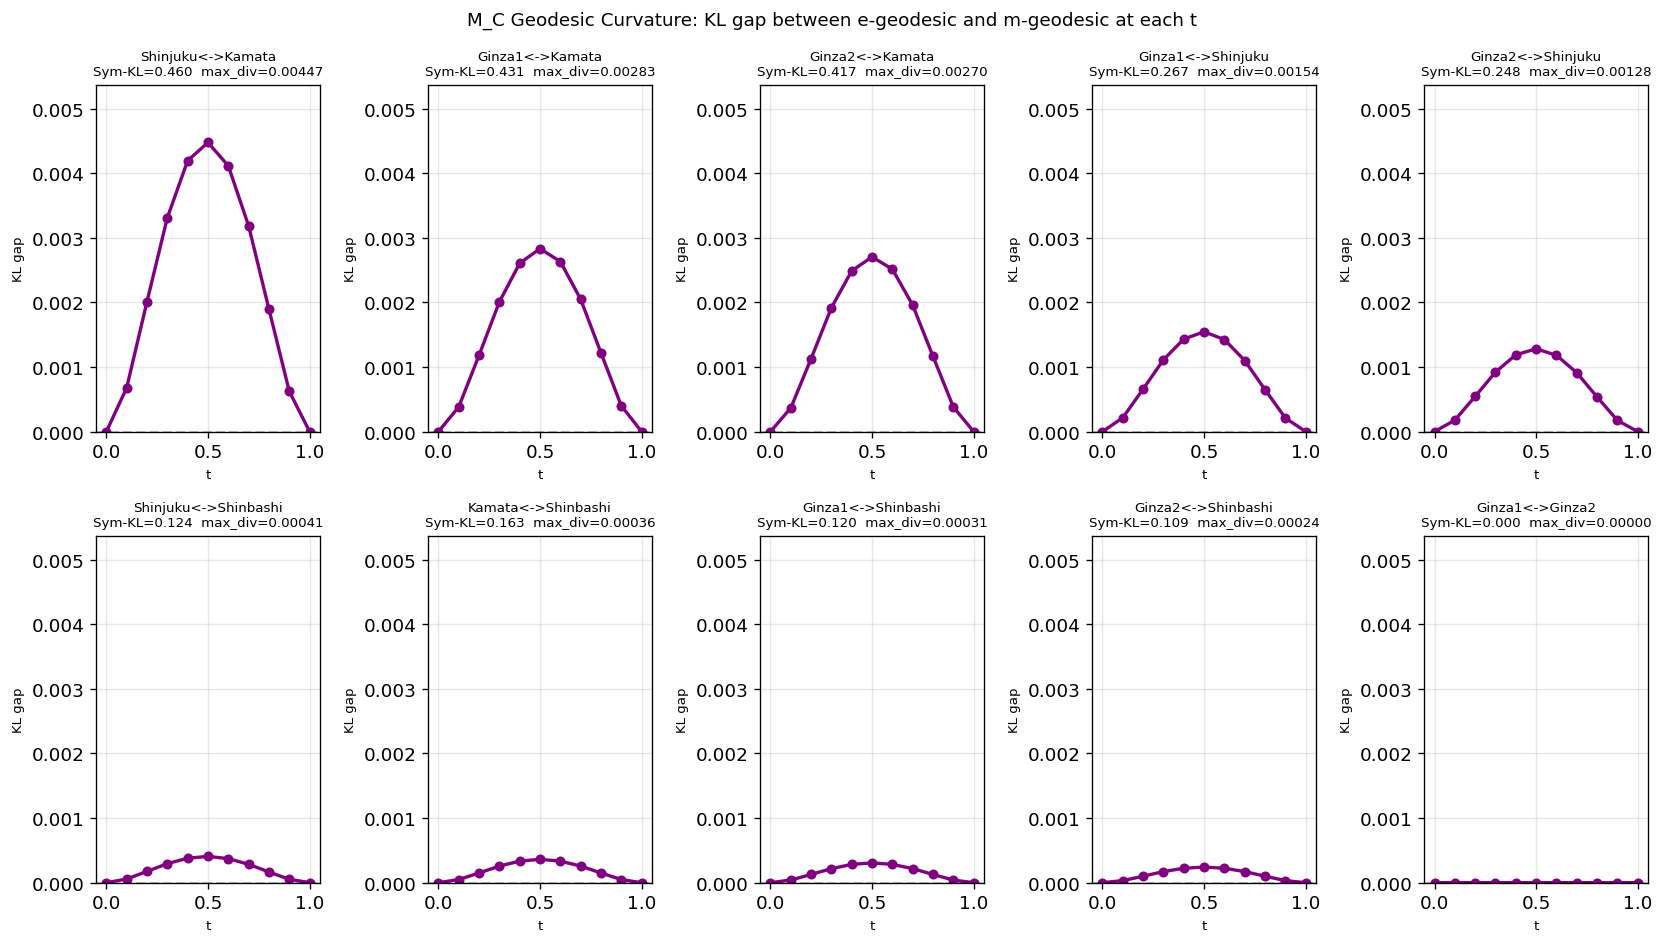


Manifold flatness: max geodesic gap = 0.004474
(Compare with M_U max gap = 0.047 from Article 4)


In [22]:
def kl_between_geodesic_points_c(theta_e, eta_m):
    """KL divergence between M_C e-geodesic point (θ) and m-geodesic point (η)."""
    params_e = theta_vec_to_scipy_c(np.array(theta_e))
    params_m = eta_vec_to_scipy_c(np.array(eta_m))
    return sum(
        KL_FUNCS[next(r[1] for r in SPATIAL_SCHEMA if r[0] == f)](params_e[f], params_m[f])
        for f in params_e
    )


def divergence_analysis_c(key_a, key_b, n_steps=11):
    """KL gap between e-geodesic and m-geodesic on M_C at each t."""
    ts, e_geo, m_geo = geodesic_points_c(key_a, key_b, n_steps)
    kl_gaps = [kl_between_geodesic_points_c(e_geo[i], m_geo[i]) for i in range(len(ts))]
    return ts, kl_gaps, e_geo, m_geo


# Compute curvature for all pairs
pair_curvatures_c = []
for i in range(n):
    for j in range(i + 1, n):
        ki, kj = keys[i], keys[j]
        ts_div, divs, e_geo, m_geo = divergence_analysis_c(ki, kj, n_steps=11)
        pair_curvatures_c.append({
            'pair':          f'{ki}<->{kj}',
            'sym_kl':        sym_kl_c[i, j],
            'max_div':       max(divs),
            'mean_div':      float(np.mean(divs[1:-1])),
            'ts':            ts_div,
            'divs':          divs,
            'e_geo':         e_geo,
            'm_geo':         m_geo,
        })

pair_curvatures_c.sort(key=lambda x: x['max_div'], reverse=True)

# ---- Summary table ----
summary_rows = []
for p in pair_curvatures_c:
    nonlinearity = 'High' if p['max_div'] > 0.04 else 'Medium' if p['max_div'] > 0.008 else 'Low'
    summary_rows.append({
        'Pair':          p['pair'],
        'Sym-KL':        round(p['sym_kl'],  5),
        'Max Div':       round(p['max_div'], 5),
        'Mean Div':      round(p['mean_div'], 5),
        'Nonlinearity':  nonlinearity,
    })
df_curv = pd.DataFrame(summary_rows)
print('=== M_C Curvature Summary (sorted by Max Div) ===')
print(df_curv.to_string(index=False))

# ---- KL gap plot for all pairs ----
n_pairs_c = len(pair_curvatures_c)
max_div_global = pair_curvatures_c[0]['max_div']

fig, axes = plt.subplots(2, (n_pairs_c + 1) // 2, figsize=(14, 8))
axes = axes.flatten()

for idx, pdata in enumerate(pair_curvatures_c):
    ax = axes[idx]
    ax.plot(pdata['ts'], pdata['divs'], 'o-', color='purple', lw=2, ms=5)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.set_ylim(0, max_div_global * 1.2)
    ax.set_xlabel('t', fontsize=8)
    ax.set_ylabel('KL gap', fontsize=8)
    ax.set_title(
        f"{pdata['pair']}\nSym-KL={pdata['sym_kl']:.3f}  max_div={pdata['max_div']:.5f}",
        fontsize=8
    )
    ax.grid(True, alpha=0.3)

for idx in range(n_pairs_c, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('M_C Geodesic Curvature: KL gap between e-geodesic and m-geodesic at each t', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mc_curvature_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nManifold flatness: max geodesic gap = {max_div_global:.6f}')
print('(Compare with M_U max gap = 0.047 from Article 4)')


## 8. M_C visualization: PCA overview

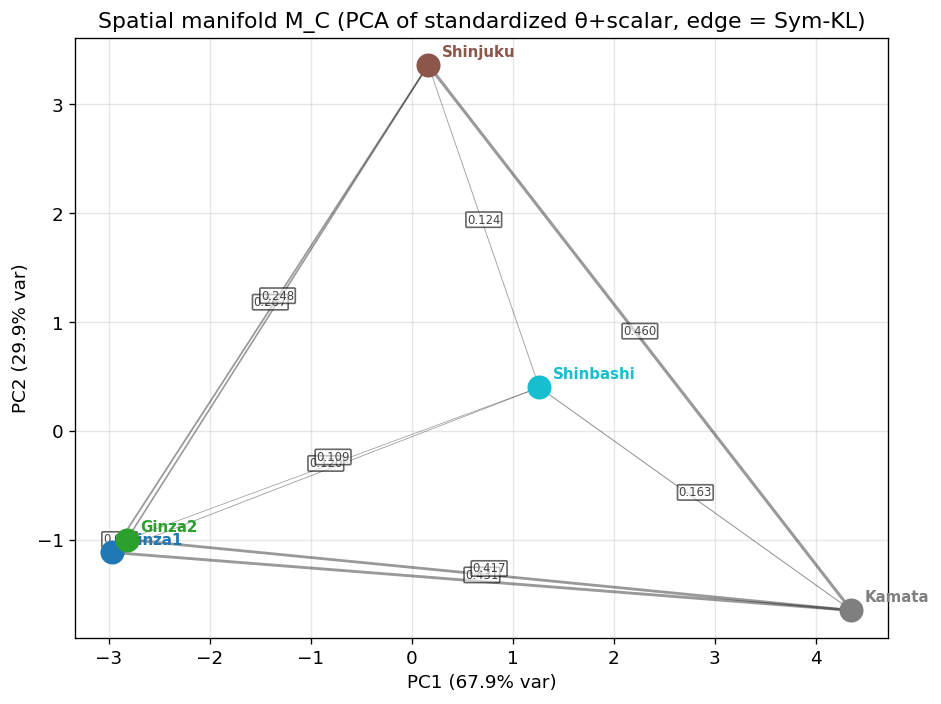

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Full M_C point = [theta_10d | scalar_1d (edge_density_km)]
mc_matrix = np.stack([
    np.concatenate([station_theta_c[k], station_scalar[k]])
    for k in keys
])
mc_scaled = StandardScaler().fit_transform(mc_matrix)
pca_c = PCA(n_components=2)
coords_2d_c = pca_c.fit_transform(mc_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = cm.tab10(np.linspace(0, 1, n))

for i, (key, coord) in enumerate(zip(keys, coords_2d_c)):
    ax.scatter(*coord, color=colors[i], s=180, zorder=5)
    ax.annotate(key, coord,
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, color=colors[i], fontweight='bold')

for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        if i < j:
            d = sym_kl_c[i, j]
            x_vals = [coords_2d_c[i, 0], coords_2d_c[j, 0]]
            y_vals = [coords_2d_c[i, 1], coords_2d_c[j, 1]]
            ax.plot(x_vals, y_vals, 'k-', alpha=0.4, lw=d * 4)
            mx, my = np.mean(x_vals), np.mean(y_vals)
            ax.text(mx, my, f'{d:.3f}', fontsize=7, ha='center', va='bottom',
                    color='#444',
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6))

ax.set_xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('Spatial manifold M_C (PCA of standardized θ+scalar, edge = Sym-KL)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mc_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. M_C vs M_U comparison

Load Sym-KL from M_U (manifold_stations.ipynb output) and compare with M_C pairwise distances.

In [24]:
# Load M_U Sym-KL — try to read from exported manifold points CSV
# If not available, fall back to recomputing from per-station JSON files

def load_mu_sym_kl():
    """Load Sym-KL matrix for M_U from exported JSON files."""
    from scipy.stats import norm, lognorm, halfnorm, gamma, beta as beta_dist
    from scipy.special import digamma

    MANIFOLD_SCHEMA_U = [
        ('real_speed_mean',     'Normal'),
        ('real_speed_cv',       'Log-normal'),
        ('real_accel_abs_mean', 'Half-normal'),
        ('stop_ratio',          'Beta'),
        ('real_straightness',   'Beta'),
        ('speed_skew',          'Gamma'),
        ('decel_ratio',         'Beta'),
        ('duration_sec',        'Log-normal'),
    ]

    def kl_normal(p, q):
        mu1, s1 = p; mu2, s2 = q
        return np.log(s2/s1) + (s1**2 + (mu1-mu2)**2)/(2*s2**2) - 0.5

    def kl_lognorm_u(p, q):
        s1, _, sc1 = p; s2, _, sc2 = q
        m1, m2 = np.log(sc1), np.log(sc2)
        return np.log(s2/s1) + (s1**2 + (m1-m2)**2)/(2*s2**2) - 0.5

    def kl_halfnormal(p, q):
        _, s1 = p; _, s2 = q
        return np.log(s2/s1) + s1**2/(2*s2**2) - 0.5

    def kl_beta_u(p, q):
        from scipy.special import betaln
        a1, b1, _, _ = p; a2, b2, _, _ = q
        return (betaln(a2, b2) - betaln(a1, b1)
                + (a1-a2)*digamma(a1) + (b1-b2)*digamma(b1)
                + (a2-a1+b2-b1)*digamma(a1+b1))

    def kl_gamma_u(p, q):
        from scipy.special import gammaln
        a1, _, sc1 = p; a2, _, sc2 = q
        return ((a1-a2)*digamma(a1) - gammaln(a1) + gammaln(a2)
                + a2*(np.log(sc2)-np.log(sc1)) + a1*(sc1/sc2 - 1))

    KL_U = {'Normal': kl_normal, 'Log-normal': kl_lognorm_u,
             'Half-normal': kl_halfnormal, 'Beta': kl_beta_u, 'Gamma': kl_gamma_u}

    station_params_u = {}
    for key in keys:
        path = MANIFOLD_U_DIR / f'{key}_dist_params.json'
        if not path.exists():
            raise FileNotFoundError(f'M_U export not found: {path}\nRun manifold_stations.ipynb first.')
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        station_params_u[key] = {feat: data[feat]['params'] for feat in data}

    mat = np.zeros((n, n))
    for i, ki in enumerate(keys):
        for j, kj in enumerate(keys):
            if i != j:
                total = 0.0
                for feat, dist_name in MANIFOLD_SCHEMA_U:
                    pp = station_params_u[ki][feat]
                    pq = station_params_u[kj][feat]
                    total += KL_U[dist_name](pp, pq)
                mat[i, j] = total
    return mat + mat.T  # Sym-KL


try:
    sym_kl_u = load_mu_sym_kl()
    print('M_U Sym-KL loaded successfully.')
    print(pd.DataFrame(sym_kl_u, index=keys, columns=keys).round(3).to_string())
except FileNotFoundError as e:
    print(f'WARNING: {e}')
    sym_kl_u = None

M_U Sym-KL loaded successfully.
           Ginza1  Ginza2  Shinjuku  Kamata  Shinbashi
Ginza1      0.000   0.352     0.383   0.332      1.113
Ginza2      0.352   0.000     0.786   0.780      1.010
Shinjuku    0.383   0.786     0.000   0.877      1.245
Kamata      0.332   0.780     0.877   0.000      2.551
Shinbashi   1.113   1.010     1.245   2.551      0.000


Spearman rank correlation: ρ=-0.297, p=0.405
                 pair  Sym-KL (M_C)  Sym-KL (M_U)
  Kamata vs Shinbashi         0.163         2.551
Shinjuku vs Shinbashi         0.124         1.245
  Ginza1 vs Shinbashi         0.120         1.113
  Ginza2 vs Shinbashi         0.109         1.010
   Shinjuku vs Kamata         0.460         0.877
   Ginza2 vs Shinjuku         0.248         0.786
     Ginza2 vs Kamata         0.417         0.780
   Ginza1 vs Shinjuku         0.267         0.383
     Ginza1 vs Ginza2         0.000         0.352
     Ginza1 vs Kamata         0.431         0.332


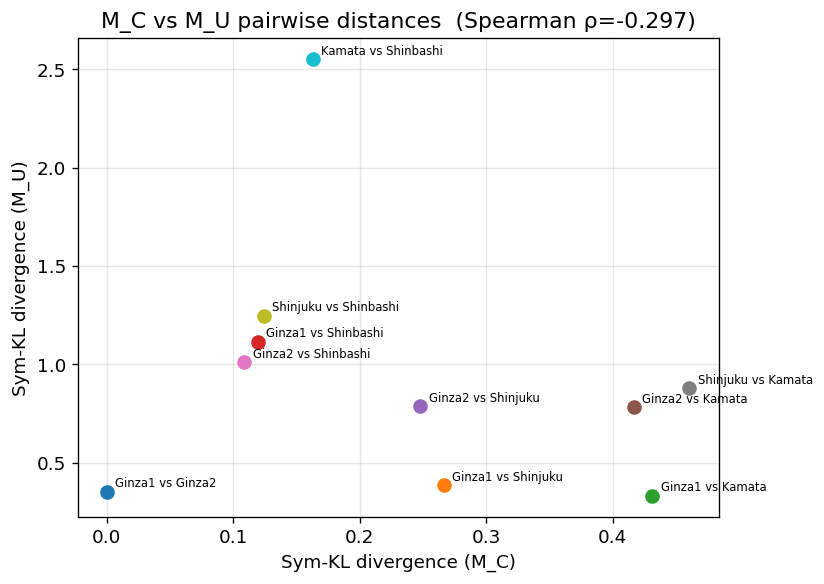

In [25]:
# Pairwise comparison table and scatter plot
if sym_kl_u is not None:
    from scipy.stats import spearmanr

    rows_cmp = []
    mc_dists, mu_kls = [], []
    for i, ki in enumerate(keys):
        for j, kj in enumerate(keys):
            if i < j:
                # M_C distance: Sym-KL divergence in θ-space
                mc_dist = sym_kl_c[i, j]
                mu_kl   = sym_kl_u[i, j]
                mc_dists.append(mc_dist)
                mu_kls.append(mu_kl)
                rows_cmp.append({
                    'pair':    f'{ki} vs {kj}',
                    'Sym-KL (M_C)': round(mc_dist, 3),
                    'Sym-KL (M_U)': round(mu_kl, 3),
                })

    df_cmp = pd.DataFrame(rows_cmp).sort_values('Sym-KL (M_U)', ascending=False).reset_index(drop=True)
    rho, pval = spearmanr(mc_dists, mu_kls)
    print(f'Spearman rank correlation: ρ={rho:.3f}, p={pval:.3f}')
    print(df_cmp.to_string(index=False))

    # Scatter plot
    fig, ax = plt.subplots(figsize=(7, 5))
    for row, mc_d, mu_k in zip(rows_cmp, mc_dists, mu_kls):
        ax.scatter(mc_d, mu_k, s=60, zorder=3)
        ax.annotate(row['pair'], (mc_d, mu_k),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax.set_xlabel('Sym-KL divergence (M_C)')
    ax.set_ylabel('Sym-KL divergence (M_U)')
    ax.set_title(f'M_C vs M_U pairwise distances  (Spearman ρ={rho:.3f})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mc_vs_mu_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping comparison (M_U data not available). Run manifold_stations.ipynb first.')

### M_C curvature vs M_U theta/eta distance

**Theoretical framing:**
- Natural parameters theta describe the generative mechanism ("invisible pressure")
- Expectation parameters eta describe observable statistics ("observed behavior")
- M_C curvature (KL gap between e-geodesic and m-geodesic) measures how much urban spatial structure's generative layer diverges from its observable layer

**Question:** Does M_C curvature between two stations correlate more strongly with M_U theta-distance (generative mechanism difference) or M_U eta-distance (observable behavior difference)?

If theta-distance tracks M_C curvature better than eta-distance, it supports the reading that urban structural curvature propagates to the generative layer of pedestrian behavior -- the "invisible pressure" analogy.

=== M_C curvature vs M_U distances ===
                 pair  M_C max_div  M_U theta-dist  M_U eta-dist  M_U sym-KL
   Shinjuku vs Kamata      0.00447         15.6215      248.0103      0.8774
     Ginza1 vs Kamata      0.00283          2.2757       56.8017      0.3320
     Ginza2 vs Kamata      0.00270          7.5834       84.9045      0.7804
   Ginza1 vs Shinjuku      0.00154         14.8407      191.2119      0.3834
   Ginza2 vs Shinjuku      0.00128         20.8394      163.1094      0.7865
Shinjuku vs Shinbashi      0.00041         22.2038      162.4706      1.2454
  Kamata vs Shinbashi      0.00036         12.3223       85.5538      2.5508
  Ginza1 vs Shinbashi      0.00031         10.8542       28.7564      1.1134
  Ginza2 vs Shinbashi      0.00024          7.0461        1.2371      1.0101
     Ginza1 vs Ginza2      0.00000          6.7160       28.1081      0.3523

Spearman rho (M_C curvature vs M_U theta-dist): 0.224  (p=0.533)
Spearman rho (M_C curvature vs M_U eta-dist  ): 

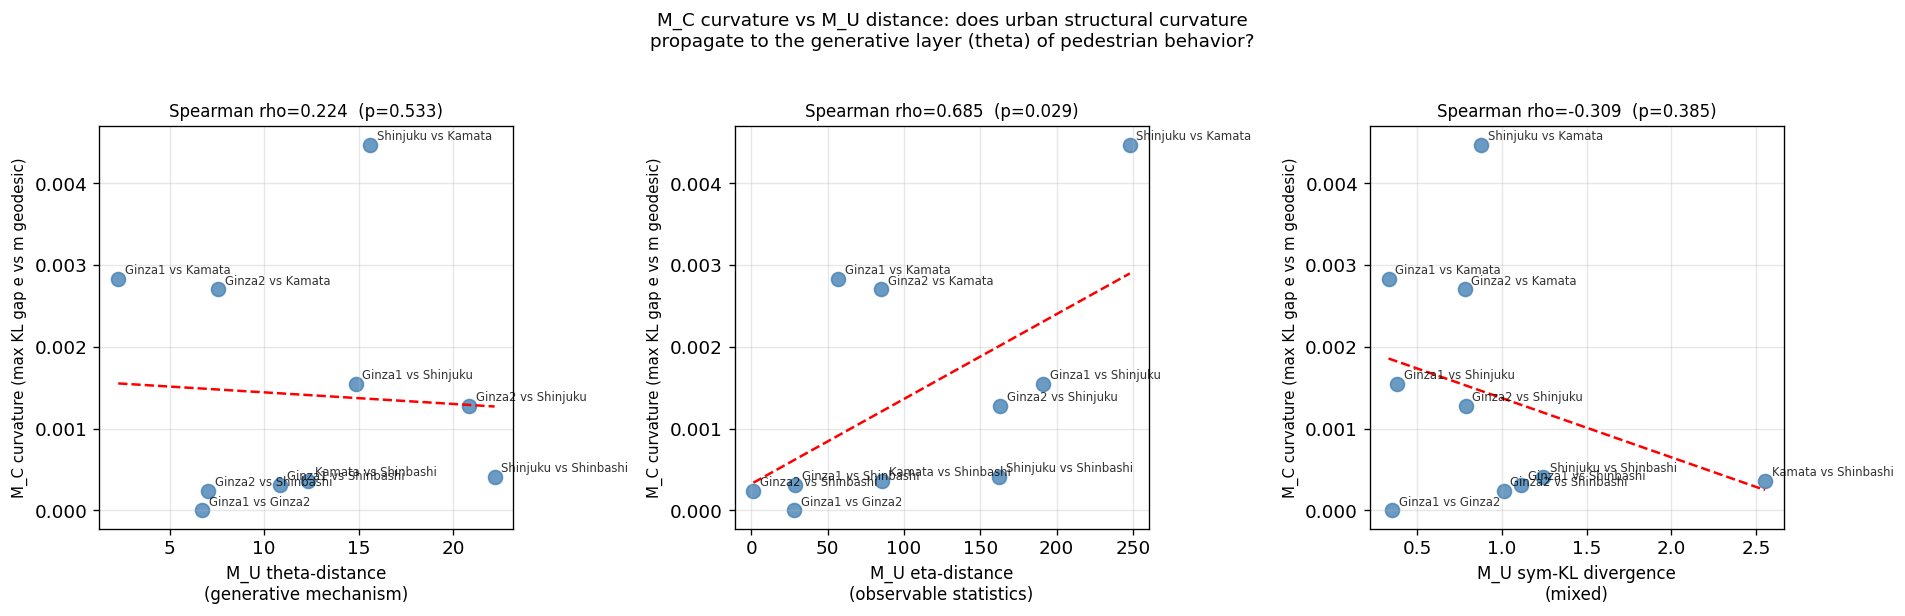

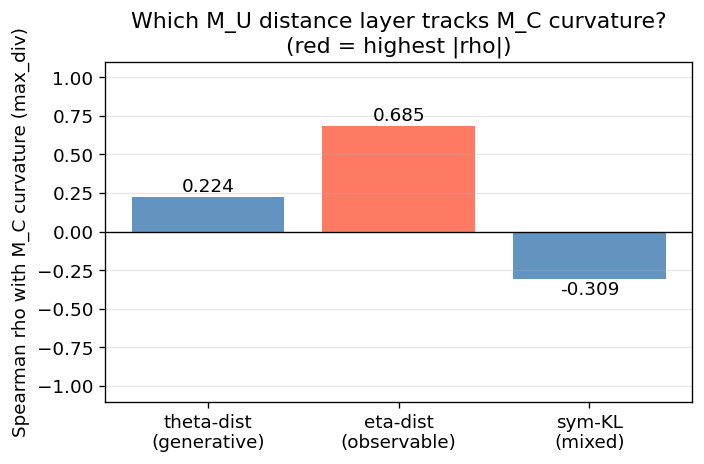


-> eta-distance aligns better with M_C curvature than theta-distance.
   Observable behavioral differences track urban curvature more than
   generative mechanism differences in this dataset.


In [19]:
if sym_kl_u is None:
    print('M_U data not available. Run manifold_stations.ipynb first.')
else:
    from scipy.stats import spearmanr

    # ── Load M_U theta and eta from per-station JSON exports ──────────────
    mu_theta, mu_eta = {}, {}
    missing = []
    for key in keys:
        path = BASE_DIR / 'output' / 'manifold' / f'{key}_dist_params.json'
        if path.exists():
            with open(path, encoding='utf-8') as f_in:
                data = json.load(f_in)
            mu_theta[key] = np.array([v for d in data.values() for v in d['theta']])
            mu_eta[key]   = np.array([v for d in data.values() for v in d['eta']])
        else:
            missing.append(key)
    if missing:
        print(f'Missing M_U exports for: {missing}. Run manifold_stations.ipynb -> Export first.')
    else:
        # ── Pairwise M_U distances ──────────────────────────────────────────
        pairs_ordered = []
        mc_curv_vals  = []
        mu_theta_dists = []
        mu_eta_dists   = []
        mu_symkl_vals  = []

        # Build lookup from pair_curvatures_c (already computed in Cell 20)
        curv_lookup = {}
        for pc in pair_curvatures_c:
            a, b = pc['pair'].split('<->')
            curv_lookup[(a.strip(), b.strip())] = pc['max_div']
            curv_lookup[(b.strip(), a.strip())] = pc['max_div']

        for i, ki in enumerate(keys):
            for j, kj in enumerate(keys):
                if i >= j:
                    continue
                key_pair = (ki, kj)
                if key_pair not in curv_lookup:
                    continue
                pairs_ordered.append(f'{ki} vs {kj}')
                mc_curv_vals.append(curv_lookup[key_pair])
                mu_theta_dists.append(np.linalg.norm(mu_theta[ki] - mu_theta[kj]))
                mu_eta_dists.append(np.linalg.norm(mu_eta[ki] - mu_eta[kj]))
                mu_symkl_vals.append(sym_kl_u[i, j])

        mc_curv_arr   = np.array(mc_curv_vals)
        theta_dist_arr = np.array(mu_theta_dists)
        eta_dist_arr   = np.array(mu_eta_dists)
        symkl_arr      = np.array(mu_symkl_vals)

        rho_theta, p_theta = spearmanr(mc_curv_arr, theta_dist_arr)
        rho_eta,   p_eta   = spearmanr(mc_curv_arr, eta_dist_arr)
        rho_kl,    p_kl    = spearmanr(mc_curv_arr, symkl_arr)

        # ── Summary table ───────────────────────────────────────────────────
        df_curv_u = pd.DataFrame({
            'pair':            pairs_ordered,
            'M_C max_div':     mc_curv_arr.round(5),
            'M_U theta-dist':  theta_dist_arr.round(4),
            'M_U eta-dist':    eta_dist_arr.round(4),
            'M_U sym-KL':      symkl_arr.round(4),
        }).sort_values('M_C max_div', ascending=False).reset_index(drop=True)
        print('=== M_C curvature vs M_U distances ===')
        print(df_curv_u.to_string(index=False))
        print()
        print(f'Spearman rho (M_C curvature vs M_U theta-dist): {rho_theta:.3f}  (p={p_theta:.3f})')
        print(f'Spearman rho (M_C curvature vs M_U eta-dist  ): {rho_eta:.3f}  (p={p_eta:.3f})')
        print(f'Spearman rho (M_C curvature vs M_U sym-KL    ): {rho_kl:.3f}  (p={p_kl:.3f})')

        # ── Scatter plots ───────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        comparisons = [
            (theta_dist_arr, rho_theta, p_theta,
             'M_U theta-distance\n(generative mechanism)'),
            (eta_dist_arr,   rho_eta,   p_eta,
             'M_U eta-distance\n(observable statistics)'),
            (symkl_arr,      rho_kl,    p_kl,
             'M_U sym-KL divergence\n(mixed)'),
        ]
        for ax, (mu_vals, rho, pval, xlabel) in zip(axes, comparisons):
            ax.scatter(mu_vals, mc_curv_arr, alpha=0.8, s=70, color='steelblue')
            for label, x, y in zip(pairs_ordered, mu_vals, mc_curv_arr):
                ax.annotate(label, (x, y), textcoords='offset points',
                            xytext=(4, 3), fontsize=7, alpha=0.8)
            m, b = np.polyfit(mu_vals, mc_curv_arr, 1)
            xs = np.linspace(mu_vals.min(), mu_vals.max(), 100)
            ax.plot(xs, m * xs + b, 'r--', lw=1.5)
            ax.set_xlabel(xlabel, fontsize=10)
            ax.set_ylabel('M_C curvature (max KL gap e vs m geodesic)', fontsize=9)
            ax.set_title(f'Spearman rho={rho:.3f}  (p={pval:.3f})', fontsize=10)
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            'M_C curvature vs M_U distance: does urban structural curvature\n'
            'propagate to the generative layer (theta) of pedestrian behavior?',
            fontsize=11, y=1.02
        )
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'mc_curvature_vs_mu_distances.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Spearman comparison bar chart ───────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 4))
        labels_bar = ['theta-dist\n(generative)', 'eta-dist\n(observable)', 'sym-KL\n(mixed)']
        rhos = [rho_theta, rho_eta, rho_kl]
        colors_bar = ['tomato' if abs(r) == max(abs(rho_theta), abs(rho_eta), abs(rho_kl))
                      else 'steelblue' for r in rhos]
        bars = ax.bar(labels_bar, rhos, color=colors_bar, alpha=0.85)
        ax.axhline(0, color='k', lw=0.8)
        for bar, r in zip(bars, rhos):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    r + 0.01 * np.sign(r), f'{r:.3f}',
                    ha='center', va='bottom' if r >= 0 else 'top', fontsize=11)
        ax.set_ylabel('Spearman rho with M_C curvature (max_div)')
        ax.set_title('Which M_U distance layer tracks M_C curvature?\n'
                     '(red = highest |rho|)')
        ax.set_ylim(-1.1, 1.1)
        ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'mc_curvature_rho_comparison.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Interpretation ──────────────────────────────────────────────────
        best = max(zip([rho_theta, rho_eta, rho_kl],
                       ['theta (generative)', 'eta (observable)', 'sym-KL (mixed)']),
                   key=lambda x: abs(x[0]))
        print()
        if abs(rho_theta) > abs(rho_eta):
            print('-> theta-distance aligns better with M_C curvature than eta-distance.')
            print('   Urban structural curvature may propagate to the generative mechanism layer')
            print('   of pedestrian behavior (supporting the "invisible pressure" analogy).')
        else:
            print('-> eta-distance aligns better with M_C curvature than theta-distance.')
            print('   Observable behavioral differences track urban curvature more than')
            print('   generative mechanism differences in this dataset.')


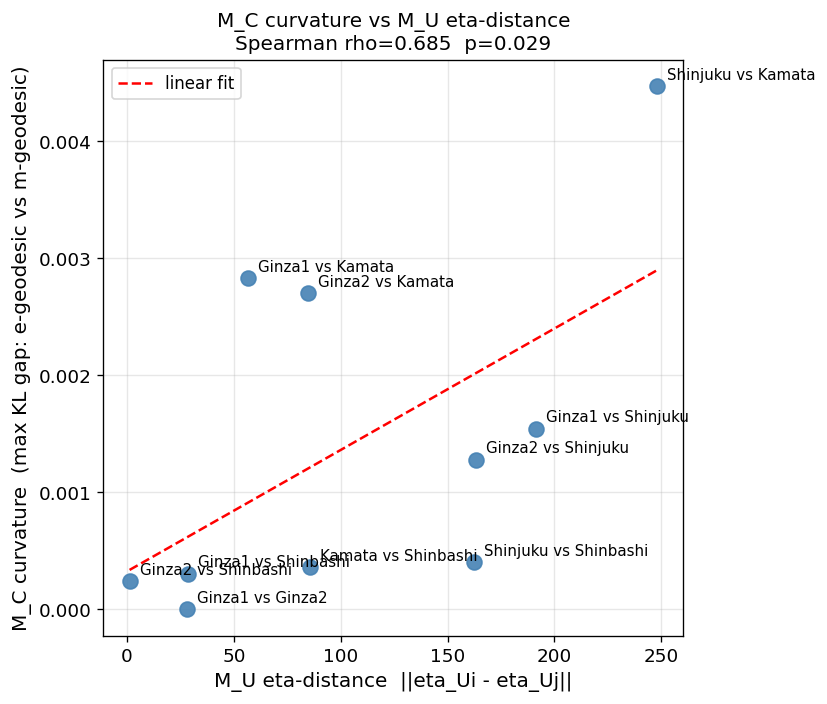

In [18]:
# M_U eta-distance vs M_C curvature: focused scatter plot
if sym_kl_u is not None and 'eta_dist_arr' in dir():
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(eta_dist_arr, mc_curv_arr, s=80, color='steelblue',
               zorder=3, alpha=0.9)

    for label, x, y in zip(pairs_ordered, eta_dist_arr, mc_curv_arr):
        ax.annotate(label, (x, y),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=9)

    m, b = np.polyfit(eta_dist_arr, mc_curv_arr, 1)
    xs = np.linspace(eta_dist_arr.min(), eta_dist_arr.max(), 200)
    ax.plot(xs, m * xs + b, 'r--', lw=1.5, label='linear fit')

    ax.set_xlabel('M_U eta-distance  ||eta_Ui - eta_Uj||', fontsize=12)
    ax.set_ylabel('M_C curvature  (max KL gap: e-geodesic vs m-geodesic)', fontsize=12)
    ax.set_title(
        f'M_C curvature vs M_U eta-distance\n'
        f'Spearman rho={rho_eta:.3f}  p={p_eta:.3f}',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mc_curvature_vs_mu_eta_dist.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Run the cell above first to compute eta_dist_arr.')


## 10. Adjoint functor analysis: F: M_C <=> M_U: G

The **adjoint functor hypothesis** (Bratton's Stack framing):
- F: M_C -> M_U maps spatial structure to predicted pedestrian behavior
- G: M_U -> M_C maps observed behavior back to inferred spatial structure
- Adjoint condition: d_U(F(c_i), u_j) corresponds to d_C(c_i, G(u_j))

In practice with 5 stations: we test whether the Sym-KL ordering on M_C
matches the Sym-KL ordering on M_U. The **adjoint gap** for a pair (i, j) is:

    gap_ij = Sym-KL_U(i,j)_norm - Sym-KL_C(i,j)_norm

- **gap > 0**: behavioral difference is larger than spatial structure predicts
  -> something beyond urban form is shaping pedestrian behavior
- **gap < 0**: spatial structure predicts more difference than actually exists
  -> urban form overestimates behavioral divergence
- **gap = 0**: perfect adjoint correspondence

The residual (where gap != 0) is what Series 2 decomposes via the
Pythagorean theorem on the dually flat manifold M_U.

=== Adjoint gap (M_U_norm - M_C_norm) ===
Positive: behavior more different than space predicts
Negative: space predicts more difference than behavior shows

                 pair  Sym-KL (M_C)  Sym-KL (M_U)  M_C (norm)  M_U (norm)  adj_gap
  Kamata vs Shinbashi        0.1632        2.5508       0.354       1.000    0.646
Shinjuku vs Shinbashi        0.1241        1.2454       0.269       0.412    0.143
  Ginza1 vs Shinbashi        0.1197        1.1134       0.259       0.352    0.093
  Ginza2 vs Shinbashi        0.1088        1.0101       0.236       0.306    0.070
     Ginza1 vs Ginza2        0.0004        0.3523       0.000       0.009    0.009
   Ginza2 vs Shinjuku        0.2478        0.7865       0.538       0.205   -0.333
   Ginza1 vs Shinjuku        0.2666        0.3834       0.579       0.023   -0.556
     Ginza2 vs Kamata        0.4167        0.7804       0.905       0.202   -0.703
   Shinjuku vs Kamata        0.4605        0.8774       1.000       0.246   -0.754
     Ginza1 

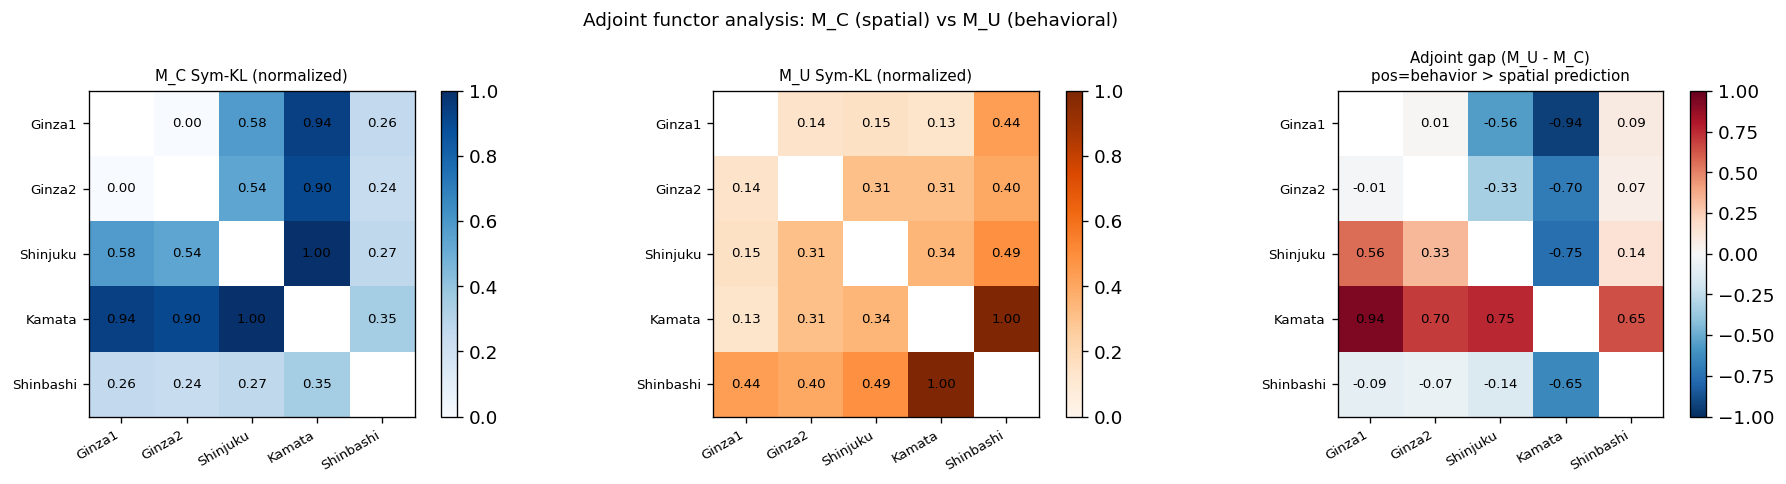

In [15]:
if sym_kl_u is None:
    print('M_U data not available. Run manifold_stations.ipynb first.')
else:
    # Extract upper-triangle pairwise values
    pairs = []
    kl_c_vals, kl_u_vals = [], []
    for i, ki in enumerate(keys):
        for j, kj in enumerate(keys):
            if i < j:
                pairs.append((ki, kj))
                kl_c_vals.append(sym_kl_c[i, j])
                kl_u_vals.append(sym_kl_u[i, j])

    kl_c_arr = np.array(kl_c_vals)
    kl_u_arr = np.array(kl_u_vals)

    # Normalize to [0, 1]
    def normalize(x):
        xmin, xmax = x.min(), x.max()
        return (x - xmin) / (xmax - xmin) if xmax > xmin else x * 0

    kl_c_norm = normalize(kl_c_arr)
    kl_u_norm = normalize(kl_u_arr)
    adj_gap   = kl_u_norm - kl_c_norm  # positive: U farther than C predicts

    # ---- Adjoint gap table ----
    df_adj = pd.DataFrame({
        'pair':         [f'{a} vs {b}' for a, b in pairs],
        'Sym-KL (M_C)': kl_c_arr.round(4),
        'Sym-KL (M_U)': kl_u_arr.round(4),
        'M_C (norm)':   kl_c_norm.round(3),
        'M_U (norm)':   kl_u_norm.round(3),
        'adj_gap':      adj_gap.round(3),
    }).sort_values('adj_gap', ascending=False).reset_index(drop=True)
    print('=== Adjoint gap (M_U_norm - M_C_norm) ===')
    print('Positive: behavior more different than space predicts')
    print('Negative: space predicts more difference than behavior shows')
    print()
    print(df_adj.to_string(index=False))

    # ---- Adjoint gap matrix heatmap ----
    gap_matrix = np.zeros((n, n))
    for idx, (ki, kj) in enumerate(pairs):
        i, j = keys.index(ki), keys.index(kj)
        gap_matrix[i, j] = adj_gap[idx]
        gap_matrix[j, i] = adj_gap[idx]  # symmetric: same gap for both directions

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, mat, title, cmap, fmt in [
        (axes[0], normalize(sym_kl_c) * np.where(np.eye(n) == 0, 1, np.nan),
         'M_C Sym-KL (normalized)', 'Blues', '.2f'),
        (axes[1], normalize(sym_kl_u) * np.where(np.eye(n) == 0, 1, np.nan),
         'M_U Sym-KL (normalized)', 'Oranges', '.2f'),
        (axes[2], gap_matrix,
         'Adjoint gap (M_U - M_C)\npos=behavior > spatial prediction', 'RdBu_r', '.2f'),
    ]:
        # build display matrix with NaN on diagonal
        disp = mat.copy()
        np.fill_diagonal(disp, np.nan)
        vmin_val = -1 if "gap" in title else 0
        im = ax.imshow(disp, cmap=cmap, vmin=vmin_val, vmax=1)
        ax.set_xticks(range(n)); ax.set_xticklabels(keys, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(n)); ax.set_yticklabels(keys, fontsize=8)
        for ii in range(n):
            for jj in range(n):
                if ii != jj:
                    ax.text(jj, ii, f'{disp[ii, jj]:{fmt}}',
                            ha='center', va='center', fontsize=8)
        plt.colorbar(im, ax=ax)
        ax.set_title(title, fontsize=9)

    plt.suptitle('Adjoint functor analysis: M_C (spatial) vs M_U (behavioral)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'adjoint_gap_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


=== Per-station neighbor ordering ===
(rank 1 = most similar, rank 4 = most different)

Ginza1:
  M_C order (close->far): Ginza2 > Shinbashi > Shinjuku > Kamata
  M_U order (close->far): Kamata > Ginza2 > Shinjuku > Shinbashi
  rank discrepancy sum:   6  (large mismatch)

Ginza2:
  M_C order (close->far): Ginza1 > Shinbashi > Shinjuku > Kamata
  M_U order (close->far): Ginza1 > Kamata > Shinjuku > Shinbashi
  rank discrepancy sum:   4  (some mismatch)

Shinjuku:
  M_C order (close->far): Shinbashi > Ginza2 > Ginza1 > Kamata
  M_U order (close->far): Ginza1 > Ginza2 > Kamata > Shinbashi
  rank discrepancy sum:   6  (large mismatch)

Kamata:
  M_C order (close->far): Shinbashi > Ginza2 > Ginza1 > Shinjuku
  M_U order (close->far): Ginza1 > Ginza2 > Shinjuku > Shinbashi
  rank discrepancy sum:   6  (large mismatch)

Shinbashi:
  M_C order (close->far): Ginza2 > Ginza1 > Shinjuku > Kamata
  M_U order (close->far): Ginza2 > Ginza1 > Shinjuku > Kamata
  rank discrepancy sum:   0  (perfect)



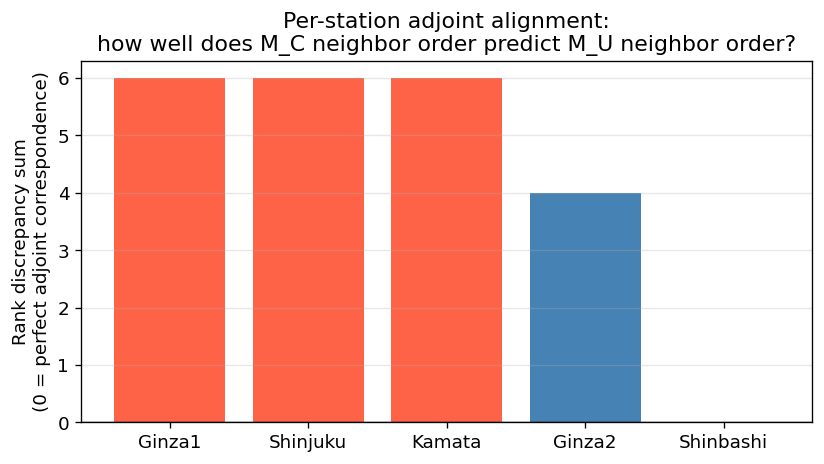

In [16]:
if sym_kl_u is not None:
    # ---- Per-station rank analysis ----
    # For each station, rank the other stations by M_C and M_U distance
    print('=== Per-station neighbor ordering ===')
    print('(rank 1 = most similar, rank 4 = most different)\n')

    rank_rows = []
    for i, ki in enumerate(keys):
        others = [kj for kj in keys if kj != ki]
        idxs   = [keys.index(kj) for kj in others]

        dists_c = np.array([sym_kl_c[i, j] for j in idxs])
        dists_u = np.array([sym_kl_u[i, j] for j in idxs])

        rank_c = np.argsort(dists_c)  # indices sorted by M_C distance
        rank_u = np.argsort(dists_u)  # indices sorted by M_U distance

        order_c = [others[r] for r in rank_c]
        order_u = [others[r] for r in rank_u]

        # Rank discrepancy: sum of |rank_C(j) - rank_U(j)| for all j
        rank_c_pos = {others[r]: r + 1 for r in range(len(others))}
        rank_u_pos = {others[r]: r + 1 for r in range(len(others))}
        for r_idx, r in enumerate(rank_c): rank_c_pos[others[r]] = r_idx + 1
        for r_idx, r in enumerate(rank_u): rank_u_pos[others[r]] = r_idx + 1
        discrepancy = sum(abs(rank_c_pos[kj] - rank_u_pos[kj]) for kj in others)

        print(f'{ki}:')
        print(f'  M_C order (close->far): {" > ".join(order_c)}')
        print(f'  M_U order (close->far): {" > ".join(order_u)}')
        print(f'  rank discrepancy sum:   {discrepancy}  '
              f'({"perfect" if discrepancy == 0 else "some mismatch" if discrepancy <= 4 else "large mismatch"})')
        print()
        rank_rows.append({'station': ki, 'M_C_order': ' > '.join(order_c),
                          'M_U_order': ' > '.join(order_u), 'discrepancy': discrepancy})

    df_rank = pd.DataFrame(rank_rows).sort_values('discrepancy', ascending=False)

    # ---- Rank discrepancy bar chart ----
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['tomato' if d > 4 else 'steelblue' if d > 0 else 'seagreen'
              for d in df_rank['discrepancy']]
    ax.bar(df_rank['station'], df_rank['discrepancy'], color=colors)
    ax.axhline(y=0, color='k', lw=0.8)
    ax.set_ylabel('Rank discrepancy sum\n(0 = perfect adjoint correspondence)')
    ax.set_title('Per-station adjoint alignment:\nhow well does M_C neighbor order predict M_U neighbor order?')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'adjoint_rank_discrepancy.png', dpi=150, bbox_inches='tight')
    plt.show()


### Connection to Pythagorean decomposition (Series 2)

The adjoint gap measured above is the empirical version of the residual in the
generalized Pythagorean theorem on M_U:

$$D(p \| r) = D(p \| q) + D(q \| r) + \langle \theta_q - \theta_r,\, \eta_p - \eta_q \rangle$$

In Series 2:
- **p** = baseline M_U point for a station (before intervention)
- **r** = perturbed M_U point (during standing demonstration)
- **q** = e-projection of r onto the submanifold predicted by M_C

Then:
- D(p || q): the behavioral shift **explained** by spatial structure
- D(q || r): the shift **residual** after spatial prediction is removed
- Inner product term: measures how far q is from being m-orthogonal to the perturbation path

Stations with **large adjoint gap** (behavior >> spatial prediction) are candidates
for having the largest perturbation residual in Series 2 -- urban form alone cannot
predict how much the Interface Layer (demonstration) shifts their behavioral manifold point.

## 11. Network visualizations

Map-style plot of each station's extracted network for visual sanity check.

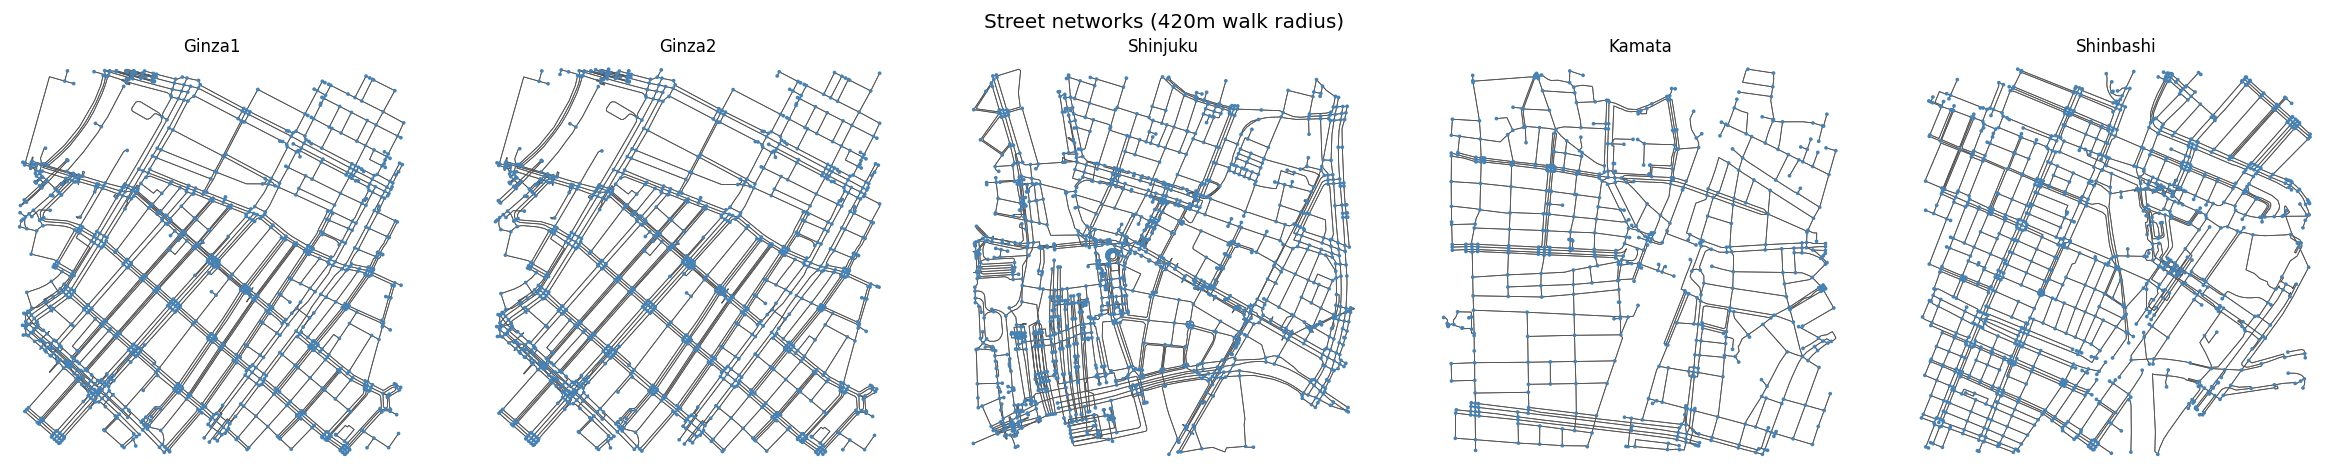

In [17]:
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, key in zip(axes, keys):
    ox.plot_graph(graphs[key], ax=ax, show=False, close=False,
                  node_size=5, edge_linewidth=0.5, bgcolor='white',
                  node_color='steelblue', edge_color='#555')
    ax.set_title(key, fontsize=10)
plt.suptitle(f'Street networks ({NETWORK_RADIUS}m walk radius)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'network_maps.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Export

In [18]:
# --- Per-station spatial distribution params + manifold coordinates ---
for key in keys:
    fits  = station_spatial_fits[key]
    feats = station_net_features[key]
    out = {}
    for feat_key, dist_name, _ in SPATIAL_SCHEMA:
        info = fits[feat_key]
        out[feat_key] = {
            'distribution': dist_name,
            'params':       list(info['params']),
            'n':            info['n'],
            'theta':        list(spatial_to_natural_params(feat_key, info['params'])),
            'eta':          list(spatial_to_expectation_params(feat_key, info['params'])),
        }
    out['_scalars'] = {
        'edge_density_km': float(feats['edge_density_km']),
    }
    out['_manifold'] = {
        'theta':  list(station_theta_c[key]),
        'eta':    list(station_eta_c[key]),
        'scalar': list(station_scalar[key]),
    }
    fpath = OUTPUT_DIR / f'{key}_spatial_params.json'
    with open(fpath, 'w', encoding='utf-8') as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f'Saved: {fpath}')

# --- KL and Sym-KL matrices ---
df_kl_out    = pd.DataFrame(kl_matrix_c, index=keys, columns=keys)
df_symkl_out = pd.DataFrame(sym_kl_c,    index=keys, columns=keys)
df_kl_out.to_csv(OUTPUT_DIR / 'kl_matrix_mc.csv')
df_symkl_out.to_csv(OUTPUT_DIR / 'sym_kl_matrix_mc.csv')
print('KL matrices saved.')

# --- Curvature summary ---
df_curv.to_csv(OUTPUT_DIR / 'mc_curvature_summary.csv', index=False)
print('Curvature summary saved.')

# --- M_C vs M_U comparison (if M_U data available) ---
if sym_kl_u is not None:
    df_cmp.to_csv(OUTPUT_DIR / 'mc_vs_mu_comparison.csv', index=False)
    df_adj.to_csv(OUTPUT_DIR / 'adjoint_gap.csv', index=False)
    df_rank.to_csv(OUTPUT_DIR / 'rank_discrepancy.csv', index=False)
    print('M_C vs M_U comparison tables saved.')
else:
    print('Skipping M_U comparison export (M_U data not available).')


Saved: ..\output\analysis\manifold_spatial\Ginza1_spatial_params.json
Saved: ..\output\analysis\manifold_spatial\Ginza2_spatial_params.json
Saved: ..\output\analysis\manifold_spatial\Shinjuku_spatial_params.json
Saved: ..\output\analysis\manifold_spatial\Kamata_spatial_params.json
Saved: ..\output\analysis\manifold_spatial\Shinbashi_spatial_params.json
KL matrices saved.
Curvature summary saved.
M_C vs M_U comparison tables saved.
